## 1. Imports and Setup


In [1]:
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

OPTS = ["A", "B", "C", "D", "E"]

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Columns    :", list(train.columns))
train.head(2)

Train shape: (2000, 8)
Test shape : (500, 7)
Columns    : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


In [2]:
row = train.iloc[0]
print("QUESTION:\n" + str(row["prompt"]) + "\n")
for opt in OPTS:
    mark = "  <-- CORRECT" if opt == row["answer"] else ""
    print(f"[{opt}] {str(row[opt])[:100]}...{mark}")

QUESTION:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

[A] Martin Heidegger believes that humans exist within a time continuum that is infinite and does not ha...
[B] Martin Heidegger believes that humans do not exist inside time, but that they are time. The relation...  <-- CORRECT
[C] Martin Heidegger does not believe in the existence of time or that it has any effect on human consci...
[D] Martin Heidegger believes that the relationship between time and human existence is cyclical. The pa...
[E] Martin Heidegger believes that time is an illusion, and the past, present, and future are all happen...


## 2. Data quality — any missing values?

A quick integrity check so nothing downstream silently breaks.

In [3]:
print("Missing values per column (train):")
print(train.isnull().sum())
print("\nTotal missing -> train:", train.isnull().sum().sum(),
      "| test:", test.isnull().sum().sum())

Missing values per column (train):
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Total missing -> train: 0 | test: 0


## 3. Which answer label is most common?

If the correct label isn't uniform across A–E, a model can exploit that position bias instead of reading the question. We check, and keep `answer_counts` for the summary dashboard later.

Count of each correct answer:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


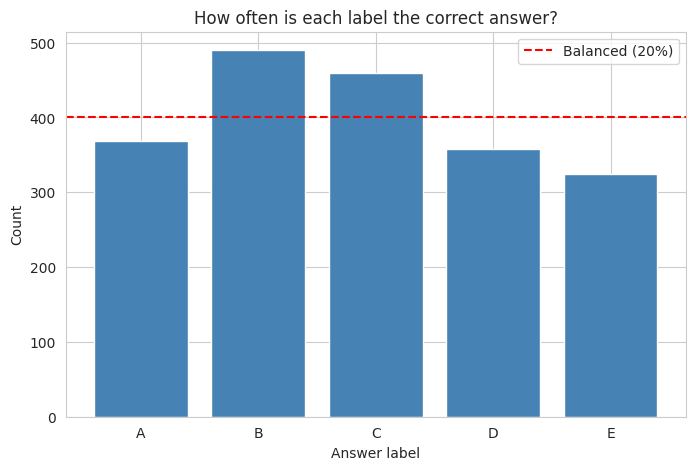

In [4]:
answer_counts = train["answer"].value_counts().reindex(OPTS)
print("Count of each correct answer:")
print(answer_counts)

plt.figure(figsize=(8, 5))
plt.bar(OPTS, answer_counts.values, color="steelblue")
plt.axhline(len(train) / 5, color="red", linestyle="--", label="Balanced (20%)")
plt.title("How often is each label the correct answer?")
plt.xlabel("Answer label"); plt.ylabel("Count"); plt.legend()
plt.show()

> **Observation.** B and C show up as the correct answer more often than A, D, E — a small **positional bias**. *Fix later:* shuffle option order during training so the model can't lean on position.

## 4. Are correct options longer than wrong ones?

If the right answer tends to be the wordiest, a model can win by counting words instead of reasoning. We build `correct_lengths` / `wrong_lengths` (reused below).

In [5]:
correct_lengths, wrong_lengths = [], []
for _, row in train.iterrows():
    for opt in OPTS:
        n = len(str(row[opt]).split())
        (correct_lengths if opt == row["answer"] else wrong_lengths).append(n)

print("Average words in CORRECT options:", round(np.mean(correct_lengths), 1))
print("Average words in WRONG options  :", round(np.mean(wrong_lengths), 1))

Average words in CORRECT options: 28.7
Average words in WRONG options  : 25.7


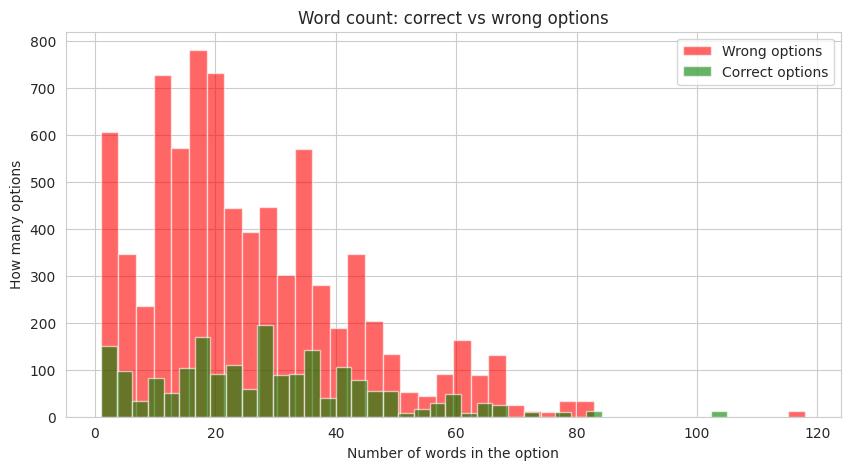

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(wrong_lengths,   bins=40, alpha=0.6, color="red",   label="Wrong options")
plt.hist(correct_lengths, bins=40, alpha=0.6, color="green", label="Correct options")
plt.title("Word count: correct vs wrong options")
plt.xlabel("Number of words in the option"); plt.ylabel("How many options")
plt.legend(); plt.show()

> **Observation.** Correct options tend to be slightly **longer**, so "always pick the longest" would beat random. 

## 5. How strong is the "pick the longest" shortcut?

Quantify exactly how far that shortcut gets you versus the 20% random baseline. `longest_is_correct` feeds the summary dashboard.

In [7]:
longest_is_correct = 0
for _, row in train.iterrows():
    lengths = [len(str(row[opt]).split()) for opt in OPTS]
    if OPTS[int(np.argmax(lengths))] == row["answer"]:
        longest_is_correct += 1

longest_pct = longest_is_correct / len(train) * 100
print(f"Longest option is correct: {longest_is_correct}/{len(train)}  ({longest_pct:.1f}%)")
print("Random baseline would be 20%.")

Longest option is correct: 699/2000  (34.9%)
Random baseline would be 20%.


> **Conclusion.** The length artifact is real and well above chance — a genuine data quirk we have to neutralize during training.

## 6. How long are the questions?

Prompt length drives tokenizer `max_len` choices for the transformer models.

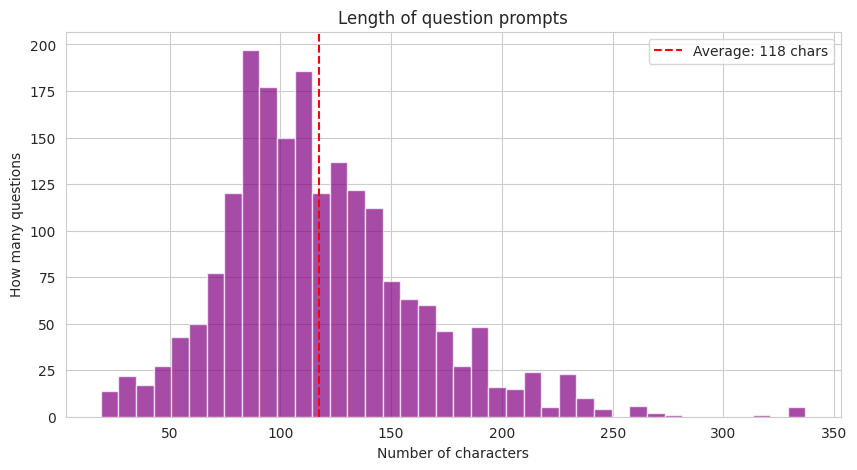

Shortest: 19 | Longest: 337 | Average: 118 characters


In [8]:
prompt_lengths = train["prompt"].str.len()

plt.figure(figsize=(10, 5))
plt.hist(prompt_lengths, bins=40, color="purple", alpha=0.7)
plt.axvline(prompt_lengths.mean(), color="red", linestyle="--",
            label=f"Average: {prompt_lengths.mean():.0f} chars")
plt.title("Length of question prompts")
plt.xlabel("Number of characters"); plt.ylabel("How many questions")
plt.legend(); plt.show()

print("Shortest:", prompt_lengths.min(), "| Longest:", prompt_lengths.max(),
      "| Average:", round(prompt_lengths.mean()), "characters")

## 7. What topics show up in the questions?

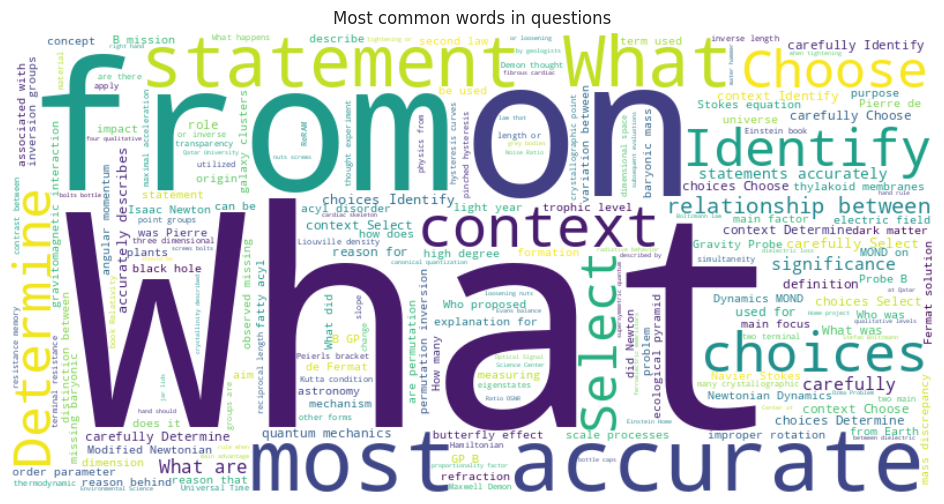

In [9]:
try:
    from wordcloud import WordCloud
    HAS_WC = True
except ImportError:
    HAS_WC = False
    print("wordcloud not installed -> pip install wordcloud")

if HAS_WC:
    boring = {"pick","best","possible","answer","following","correct","option","the",
              "is","a","an","of","to","and","in","among","listed","options","which",
              "based","given"}
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=boring, colormap="viridis"
                  ).generate(" ".join(train["prompt"].astype(str).tolist()))
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title("Most common words in questions"); plt.show()

## 8. Do train and test share questions?

If test prompts already appear in train, we know their correct answer text for free. `shared_prompts` is reused in the summary.

In [10]:
train_prompts = set(train["prompt"])
test_prompts  = set(test["prompt"])
shared_prompts = train_prompts & test_prompts

print("Unique prompts in train:", len(train_prompts))
print("Unique prompts in test :", len(test_prompts))
print("Prompts in BOTH         :", len(shared_prompts))
overlap_pct = len(shared_prompts) / len(test) * 100
print(f"\n{overlap_pct:.1f}% of test questions also appear in train.")

Unique prompts in train: 1758
Unique prompts in test : 492
Prompts in BOTH         : 267

53.4% of test questions also appear in train.


## 9. How many test answers can we look up directly?

Overlap only helps if the **known correct answer text** is actually one of that test row's options. 

In [11]:
correct_answer_text = {row["prompt"]: row[row["answer"]] for _, row in train.iterrows()}

matches = 0
for _, row in test.iterrows():
    known = correct_answer_text.get(row["prompt"])
    if known is not None and known in [row[opt] for opt in OPTS]:
        matches += 1

lookup_pct = matches / len(test) * 100
print(f"Test rows whose answer is already known from train: {matches}")
print(f"That is {lookup_pct:.1f}% of the test set.")

Test rows whose answer is already known from train: 262
That is 52.4% of the test set.


## 10. Everything on one page

The four findings that shape the modelling strategy, side by side.

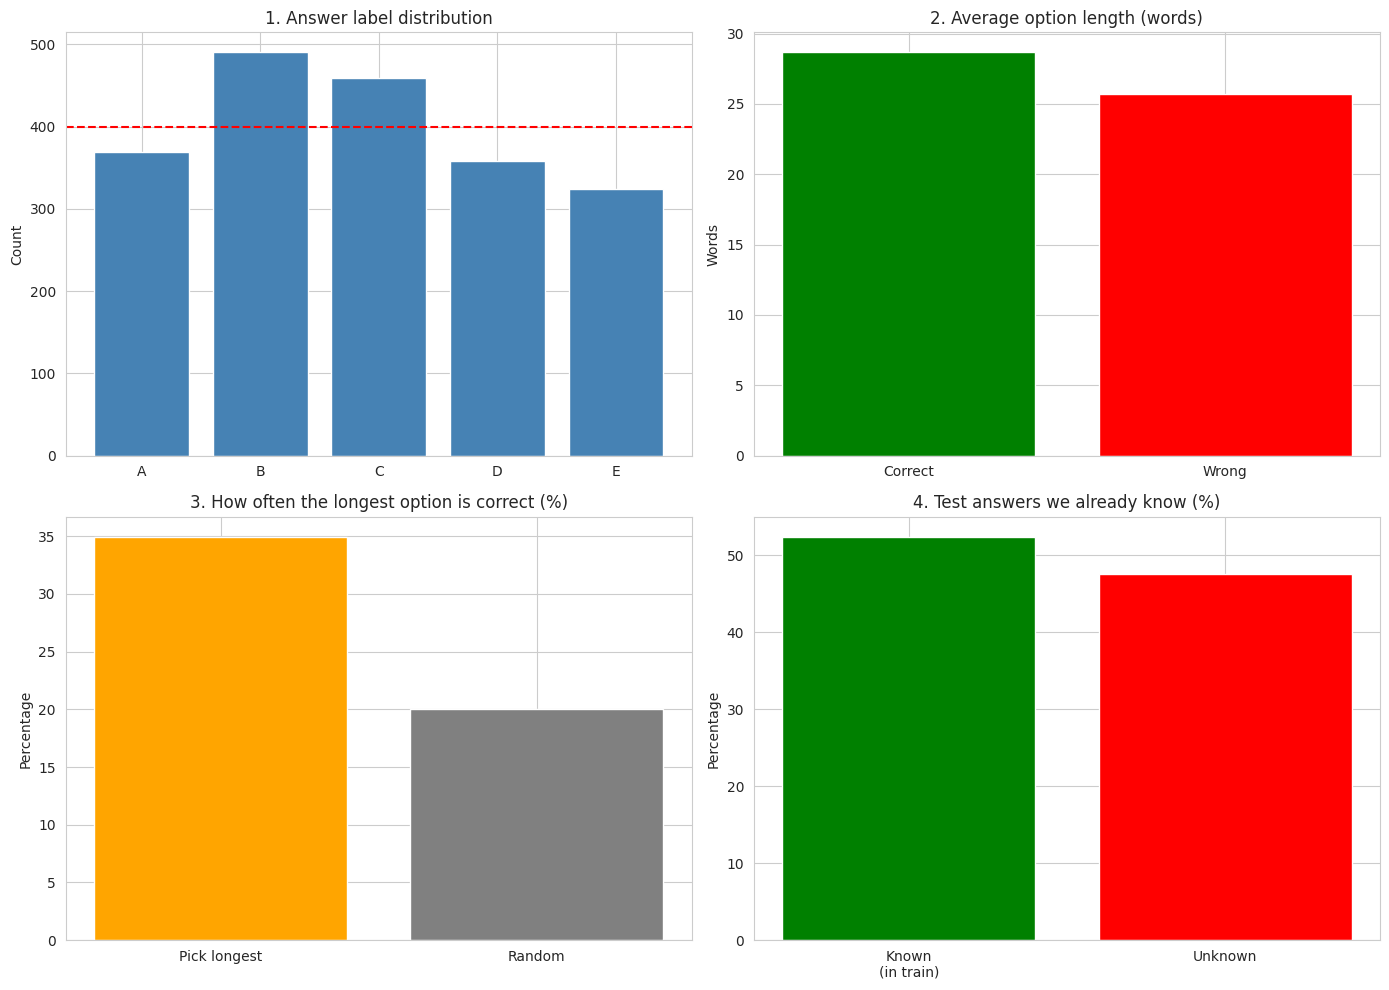

In [12]:
avg_correct = np.mean(correct_lengths)
avg_wrong   = np.mean(wrong_lengths)

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].bar(OPTS, answer_counts.values, color="steelblue")
ax[0,0].axhline(len(train)/5, color="red", linestyle="--")
ax[0,0].set_title("1. Answer label distribution"); ax[0,0].set_ylabel("Count")

ax[0,1].bar(["Correct","Wrong"], [avg_correct, avg_wrong], color=["green","red"])
ax[0,1].set_title("2. Average option length (words)"); ax[0,1].set_ylabel("Words")

ax[1,0].bar(["Pick longest","Random"], [longest_pct, 20], color=["orange","gray"])
ax[1,0].set_title("3. How often the longest option is correct (%)")
ax[1,0].set_ylabel("Percentage")

ax[1,1].bar(["Known\n(in train)","Unknown"], [lookup_pct, 100-lookup_pct],
            color=["green","red"])
ax[1,1].set_title("4. Test answers we already know (%)")
ax[1,1].set_ylabel("Percentage")

plt.tight_layout(); plt.show()

## 11. Key findings

In [13]:
print("           EDA SUMMARY - KEY FINDINGS")

print(f"1. Dataset: {len(train)} train rows, {len(test)} test rows")
print(f"2. Labels B and C are most common as correct answers")
print(f"3. Correct options are longer: {avg_correct:.0f} vs {avg_wrong:.0f} words")
print(f"4. Longest option is correct {longest_pct:.0f}% of the time (random = 20%)")
print(f"5. {overlap_pct:.0f}% of test questions also appear in train")
print(f"6. We can directly look up {lookup_pct:.0f}% of test answers")

           EDA SUMMARY - KEY FINDINGS
1. Dataset: 2000 train rows, 500 test rows
2. Labels B and C are most common as correct answers
3. Correct options are longer: 29 vs 26 words
4. Longest option is correct 35% of the time (random = 20%)
5. 53% of test questions also appear in train
6. We can directly look up 52% of test answers
